# Credit Card Approval Prediction Using Machine Learning

## Project Overview

This project predicts whether a credit card application will be approved or rejected using Machine Learning algorithms.

### Algorithms Used
- Logistic Regression
- Decision Tree
- Random Forest
- XGBoost

### Technologies
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- XGBoost

### Objective

To automate credit card approval prediction using historical applicant and credit history data.

In [1]:
# ==========================================
# Import Required Libraries
# ==========================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import joblib

print("All libraries imported successfully.")

All libraries imported successfully.


In [2]:
# ==========================================
# Load Datasets
# ==========================================

application = pd.read_csv("../dataset/application_record.csv")
credit = pd.read_csv("../dataset/credit_record.csv")

print("Application Dataset Shape :", application.shape)
print("Credit Dataset Shape :", credit.shape)

Application Dataset Shape : (438557, 18)
Credit Dataset Shape : (1048575, 3)


In [3]:
application.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0


In [4]:
credit.head()

,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C


In [5]:
application.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438557 entries, 0 to 438556
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   438557 non-null  int64  
 1   CODE_GENDER          438557 non-null  object 
 2   FLAG_OWN_CAR         438557 non-null  object 
 3   FLAG_OWN_REALTY      438557 non-null  object 
 4   CNT_CHILDREN         438557 non-null  int64  
 5   AMT_INCOME_TOTAL     438557 non-null  float64
 6   NAME_INCOME_TYPE     438557 non-null  object 
 7   NAME_EDUCATION_TYPE  438557 non-null  object 
 8   NAME_FAMILY_STATUS   438557 non-null  object 
 9   NAME_HOUSING_TYPE    438557 non-null  object 
 10  DAYS_BIRTH           438557 non-null  int64  
 11  DAYS_EMPLOYED        438557 non-null  int64  
 12  FLAG_MOBIL           438557 non-null  int64  
 13  FLAG_WORK_PHONE      438557 non-null  int64  
 14  FLAG_PHONE           438557 non-null  int64  
 15  FLAG_EMAIL       

In [6]:
credit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 3 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   ID              1048575 non-null  int64 
 1   MONTHS_BALANCE  1048575 non-null  int64 
 2   STATUS          1048575 non-null  object
dtypes: int64(2), object(1)
memory usage: 24.0+ MB


In [7]:
application.isnull().sum()

ID                          0
CODE_GENDER                 0
FLAG_OWN_CAR                0
FLAG_OWN_REALTY             0
CNT_CHILDREN                0
AMT_INCOME_TOTAL            0
NAME_INCOME_TYPE            0
NAME_EDUCATION_TYPE         0
NAME_FAMILY_STATUS          0
NAME_HOUSING_TYPE           0
DAYS_BIRTH                  0
DAYS_EMPLOYED               0
FLAG_MOBIL                  0
FLAG_WORK_PHONE             0
FLAG_PHONE                  0
FLAG_EMAIL                  0
OCCUPATION_TYPE        134203
CNT_FAM_MEMBERS             0
dtype: int64

In [8]:
credit.isnull().sum()

ID                0
MONTHS_BALANCE    0
STATUS            0
dtype: int64

In [9]:
print("Application Duplicate Rows :", application.duplicated().sum())
print("Credit Duplicate Rows :", credit.duplicated().sum())

Application Duplicate Rows : 0
Credit Duplicate Rows : 0


In [10]:
application.describe()

,ID,CNT_CHILDREN,AMT_INCOME_TOTAL,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS
count,4.385570e+05,438557.000000,4.385570e+05,438557.000000,438557.000000,438557.0,438557.000000,438557.000000,438557.000000,438557.000000
mean,6.022176e+06,0.427390,1.875243e+05,-15997.904649,60563.675328,1.0,0.206133,0.287771,0.108207,2.194465
std,5.716370e+05,0.724882,1.100869e+05,4185.030007,138767.799647,0.0,0.404527,0.452724,0.310642,0.897207
min,5.008804e+06,0.000000,2.610000e+04,-25201.000000,-17531.000000,1.0,0.000000,0.000000,0.000000,1.000000
25%,5.609375e+06,0.000000,1.215000e+05,-19483.000000,-3103.000000,1.0,0.000000,0.000000,0.000000,2.000000
50%,6.047745e+06,0.000000,1.607805e+05,-15630.000000,-1467.000000,1.0,0.000000,0.000000,0.000000,2.000000
75%,6.456971e+06,1.000000,2.250000e+05,-12514.000000,-371.000000,1.0,0.000000,1.000000,0.000000,3.000000
max,7.999952e+06,19.000000,6.750000e+06,-7489.000000,365243.000000,1.0,1.000000,1.000000,1.000000,20.000000


## Exploratory Data Analysis (EDA)

In [11]:
# Missing Values
missing_values = application.isnull().sum().sort_values(ascending=False)
missing_values

OCCUPATION_TYPE        134203
ID                          0
CODE_GENDER                 0
FLAG_EMAIL                  0
FLAG_PHONE                  0
FLAG_WORK_PHONE             0
FLAG_MOBIL                  0
DAYS_EMPLOYED               0
DAYS_BIRTH                  0
NAME_HOUSING_TYPE           0
NAME_FAMILY_STATUS          0
NAME_EDUCATION_TYPE         0
NAME_INCOME_TYPE            0
AMT_INCOME_TOTAL            0
CNT_CHILDREN                0
FLAG_OWN_REALTY             0
FLAG_OWN_CAR                0
CNT_FAM_MEMBERS             0
dtype: int64

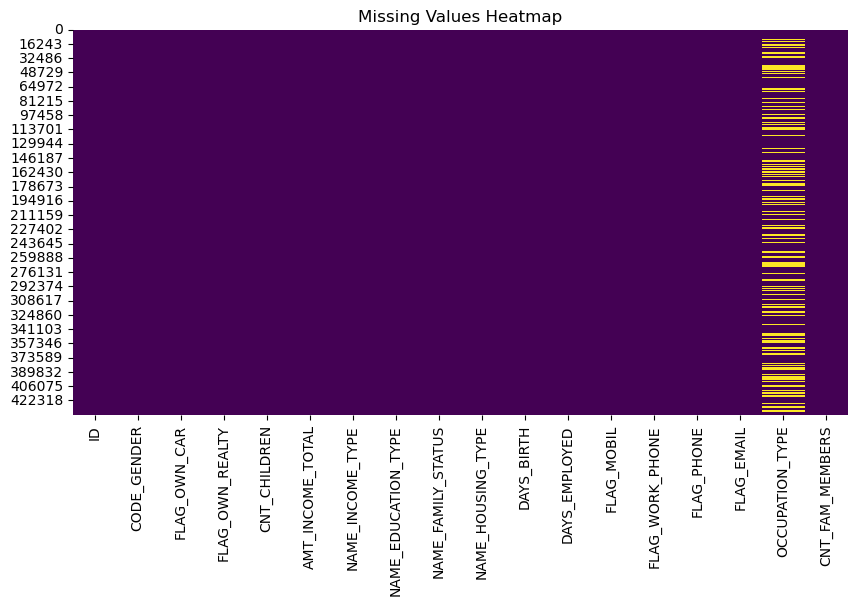

In [12]:
plt.figure(figsize=(10,5))
sns.heatmap(application.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.show()

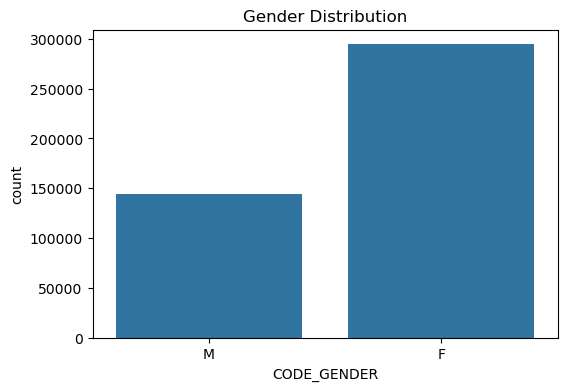

In [13]:
plt.figure(figsize=(6,4))
sns.countplot(x='CODE_GENDER', data=application)
plt.title("Gender Distribution")
plt.show()

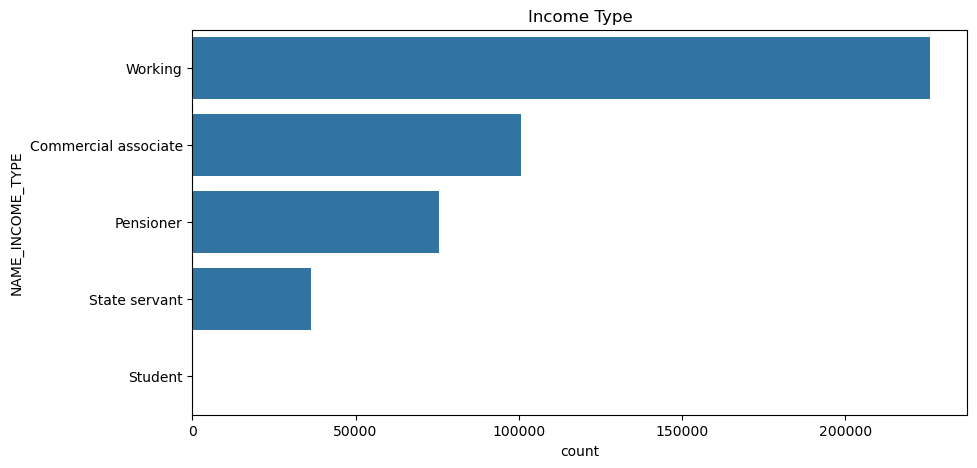

In [14]:
plt.figure(figsize=(10,5))
sns.countplot(y='NAME_INCOME_TYPE', data=application)
plt.title("Income Type")
plt.show()

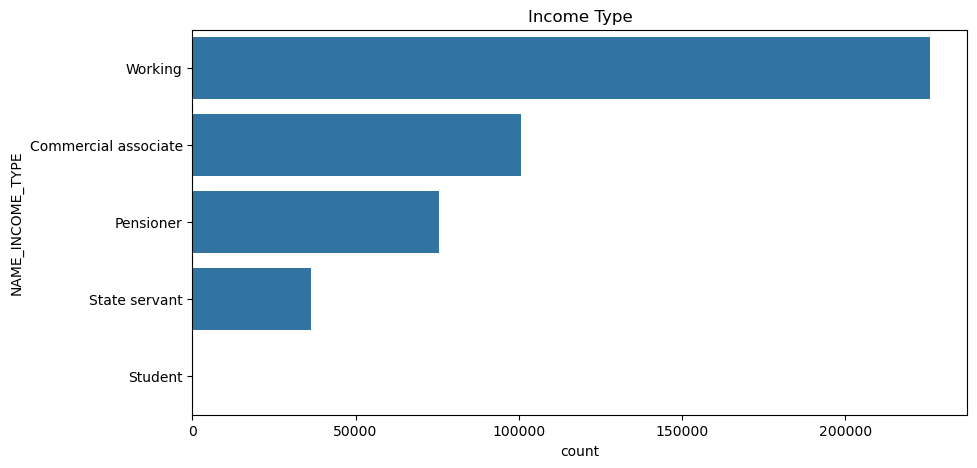

In [15]:
plt.figure(figsize=(10,5))
sns.countplot(y='NAME_INCOME_TYPE', data=application)
plt.title("Income Type")
plt.show()

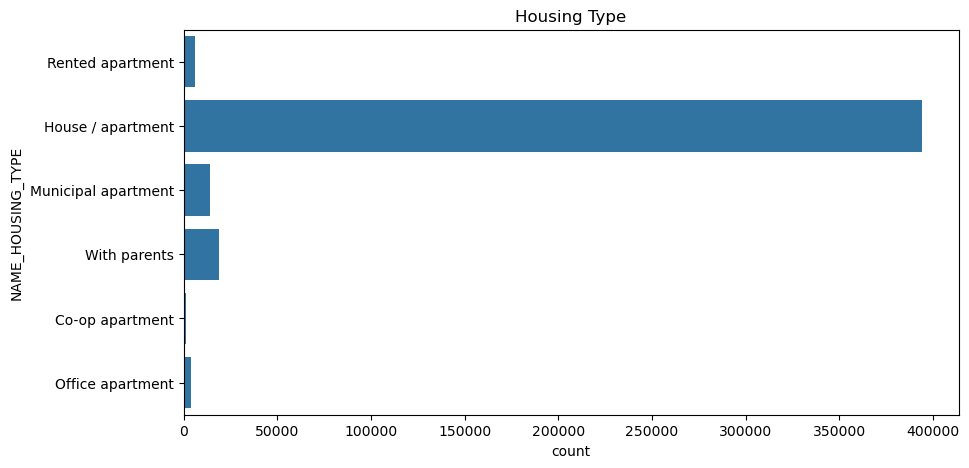

In [16]:
plt.figure(figsize=(10,5))
sns.countplot(y='NAME_HOUSING_TYPE', data=application)
plt.title("Housing Type")
plt.show()

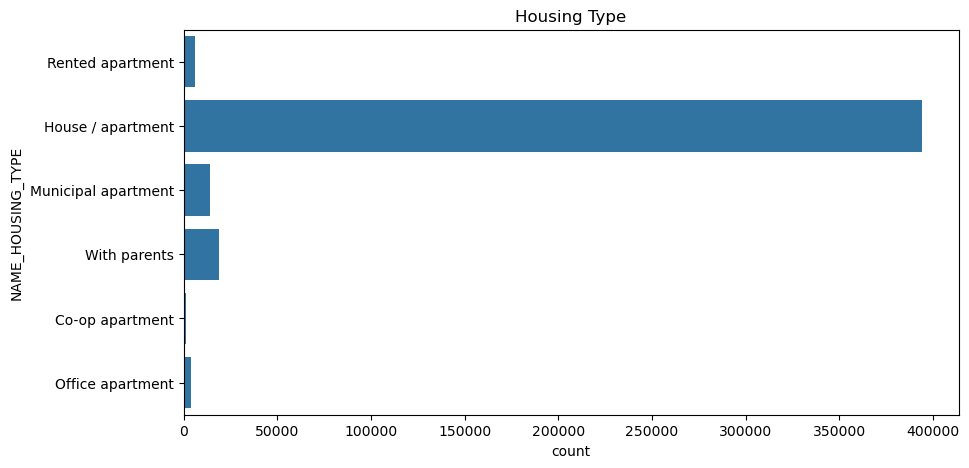

In [17]:
plt.figure(figsize=(10,5))
sns.countplot(y='NAME_HOUSING_TYPE', data=application)
plt.title("Housing Type")
plt.show()

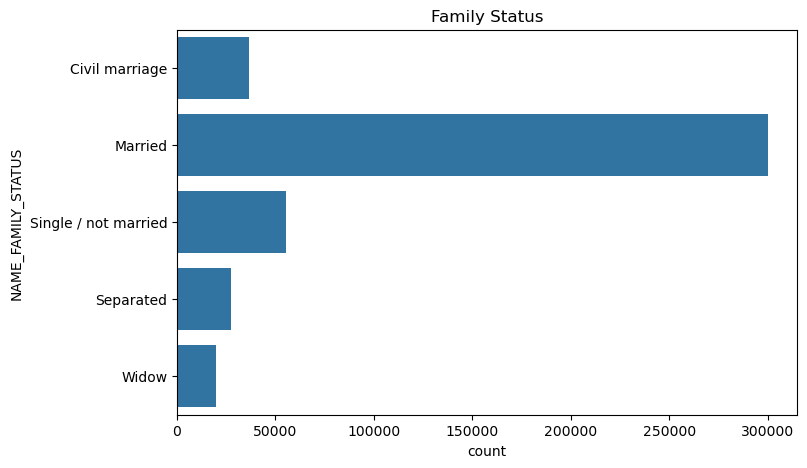

In [18]:
plt.figure(figsize=(8,5))
sns.countplot(y='NAME_FAMILY_STATUS', data=application)
plt.title("Family Status")
plt.show()

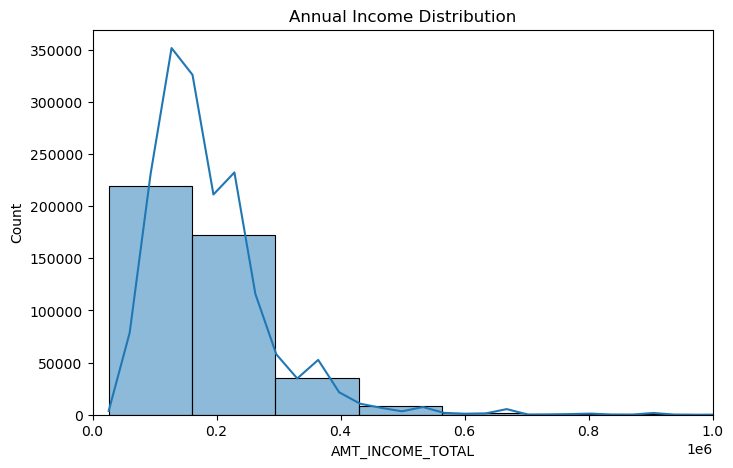

In [19]:
plt.figure(figsize=(8,5))
sns.histplot(application['AMT_INCOME_TOTAL'], bins=50, kde=True)
plt.title("Annual Income Distribution")
plt.xlim(0, 1000000)
plt.show()

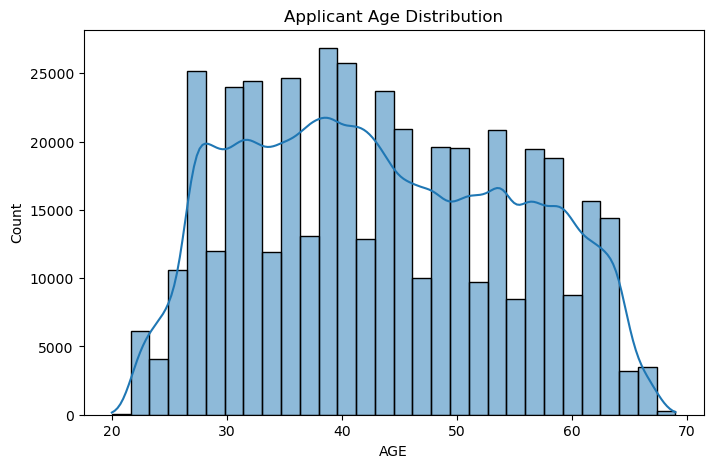

In [20]:
application['AGE'] = (-application['DAYS_BIRTH'] / 365).astype(int)

plt.figure(figsize=(8,5))
sns.histplot(application['AGE'], bins=30, kde=True)
plt.title("Applicant Age Distribution")
plt.show()

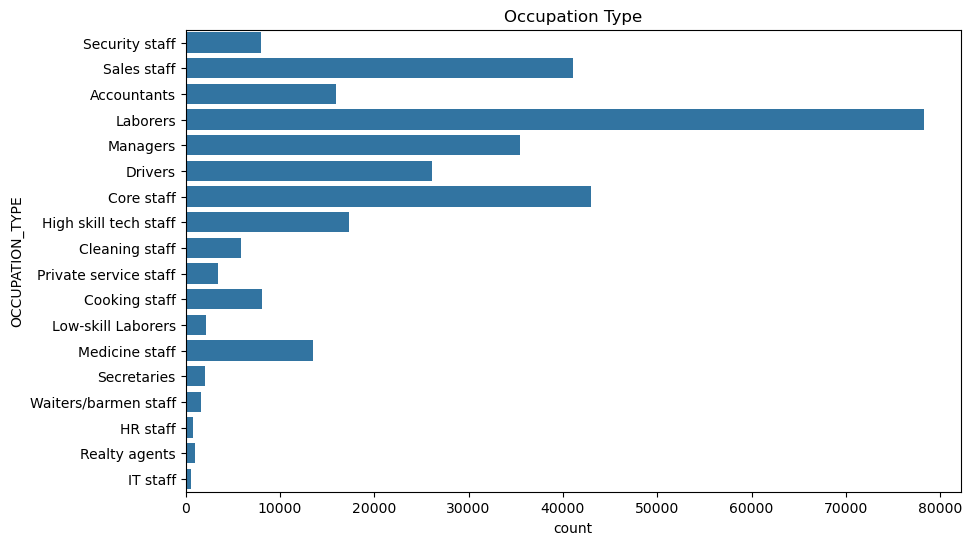

In [21]:
plt.figure(figsize=(10,6))
sns.countplot(y='OCCUPATION_TYPE', data=application)
plt.title("Occupation Type")
plt.show()

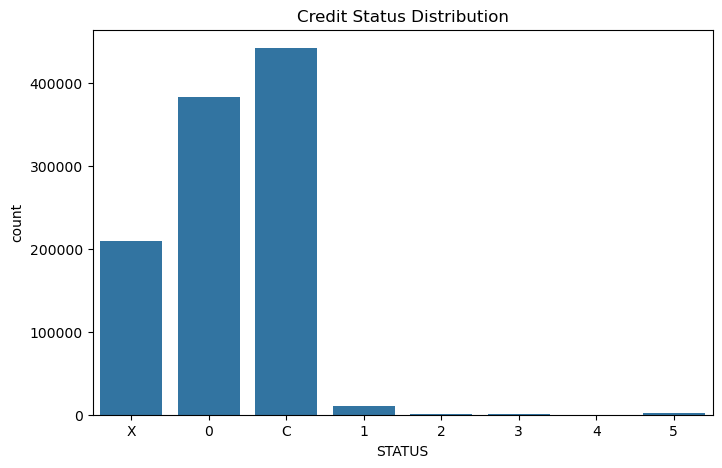

In [22]:
plt.figure(figsize=(8,5))
sns.countplot(x='STATUS', data=credit)
plt.title("Credit Status Distribution")
plt.show()

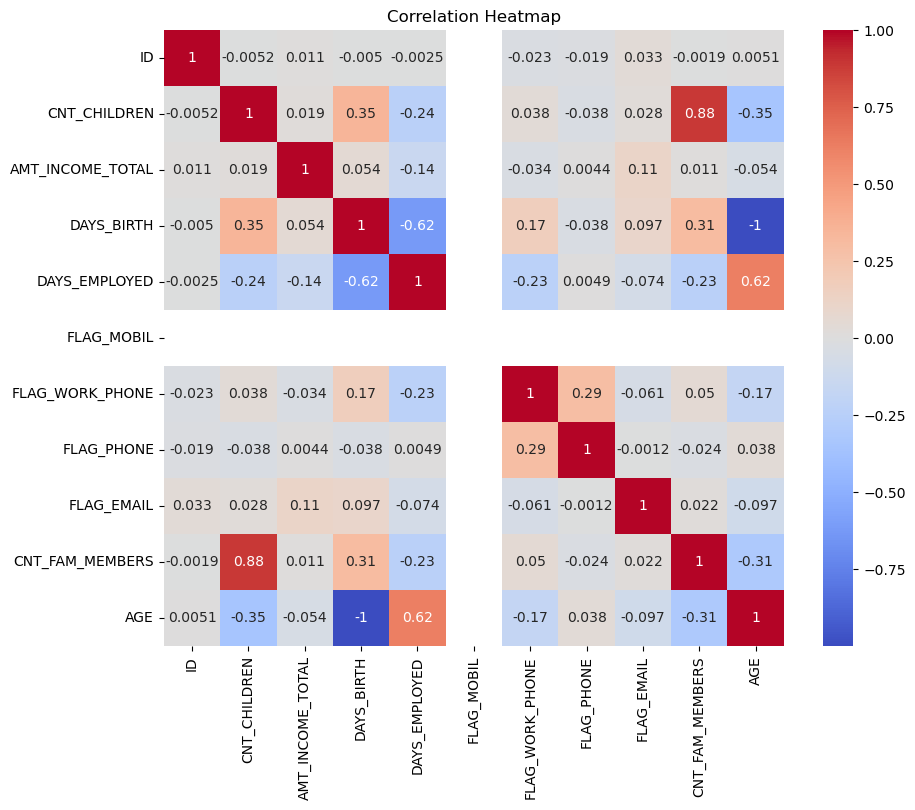

In [23]:
plt.figure(figsize=(10,8))

numeric_columns = application.select_dtypes(include=['int64', 'float64'])

sns.heatmap(numeric_columns.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()